# US Large-Cap Tech Stock Risk-Return Analysis
## Analytical Objective
This analysis evaluates the risk-return profile of 6 leading US tech stocks (MSFT, AAPL, AMZN, GOOGL, META, TSLA) over the 2020-2024 period, with a direct comparison to the broad US market benchmark. The goal is to identify optimal risk-adjusted investment opportunities for retail and institutional investors building a tech-focused equity portfolio.

## Data Source
All data is retrieved from the Wharton Research Data Services (WRDS) CRSP (Center for Research in Security Prices) database, the gold standard for US equity market research:
- `crsp.msf`: Monthly Stock File, containing end-of-month closing prices and total returns for all US listed equities
- `crsp.msfhdr`: Stock Header File, providing the official mapping between ticker symbols and CRSP permanent security identifiers (PERMNO)
- `crsp.msi`: Monthly Market Index File, containing the CRSP value-weighted market return (broad US market benchmark)

## Analysis Framework
1.  Data retrieval via structured SQL queries
2.  Comprehensive data cleaning and validation
3.  Core risk-return metric calculation (cumulative return, volatility, Sharpe ratio, max drawdown, excess return)
4.  Rebased cumulative return calculation (all series normalized to a 100 starting point for fair comparison)
5.  Multi-dimensional visualization of performance and risk
6.  Full result export for reporting and portfolio decision-making

In [1]:
# Install WRDS Python module if not already installed
!pip install wrds -q

# Import core libraries for data retrieval, analysis, and visualization
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from typing import List

# Suppress non-critical warnings for clean output
warnings.filterwarnings('ignore')

# Set academic-standard visualization formatting for assignment submission
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# Auto-create structured backup folder on your desktop
MAIN_BACKUP_PATH = os.path.join(os.path.expanduser("~"), "Desktop", "Tech_Stock_Analysis_WRDS")
for subfolder in ["01_Raw_WRDS_Data", "02_Cleaned_Processed_Data", "03_Analysis_Results", "04_Visualizations"]:
    os.makedirs(os.path.join(MAIN_BACKUP_PATH, subfolder), exist_ok=True)

# Confirm setup completion
print("✅ Setup complete. Backup folder created at:", MAIN_BACKUP_PATH)

✅ Setup complete. Backup folder created at: C:\Users\lanove\Desktop\Tech_Stock_Analysis_WRDS


In [2]:
# --------------------------
# WRDS Database Connection
# --------------------------
# INSTRUCTION: Enter your WRDS username inside the quotation marks below
WRDS_USERNAME = ""  # Input your WRDS username here (e.g. your.name24@student.xjtlu.edu.cn)

# Establish connection to WRDS
try:
    db = wrds.Connection(wrds_username=WRDS_USERNAME)
    print("✅ Successfully connected to WRDS database")
except Exception as e:
    print(f"⚠️  WRDS connection failed: {str(e)}")
    print("ℹ️  Falling back to simulated CRSP-format data for testing")
    db = None

Enter your WRDS username [lanove]: huangyitong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\lanove\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Successfully connected to WRDS database


In [3]:
# --------------------------
# Customizable Analysis Parameters
# --------------------------
# List of target stocks for analysis
TARGET_TICKERS = ['MSFT', 'AAPL', 'AMZN', 'GOOGL', 'META', 'TSLA']

# Analysis time horizon
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

# Market benchmark for relative performance analysis
MARKET_BENCHMARK = "vwretd"  # CRSP Value-Weighted Market Return

# Rolling window for volatility calculation
ROLLING_WINDOW = 6

# Print parameter summary
print("📊 Analysis Parameters:")
print(f"Target Stocks: {', '.join(TARGET_TICKERS)}")
print(f"Time Period: {START_DATE} to {END_DATE}")
print(f"Market Benchmark: {MARKET_BENCHMARK.upper()}")

📊 Analysis Parameters:
Target Stocks: MSFT, AAPL, AMZN, GOOGL, META, TSLA
Time Period: 2020-01-01 to 2024-12-31
Market Benchmark: VWRETD


In [4]:
# --------------------------
# Retrieve Stock Data from WRDS
# --------------------------
def fetch_stock_data(
    db_connection,
    ticker_list: List[str],
    start_date: str,
    end_date: str
) -> pd.DataFrame:
    """
    Reusable function to retrieve monthly stock data from WRDS CRSP
    Joins monthly price/return data with ticker-PERMNO mapping for targeted ticker selection
    """
    # Fallback to simulated data if no WRDS connection
    if db_connection is None:
        dates = pd.date_range(start=start_date, end=end_date, freq='M')
        data_list = []
        for ticker in ticker_list:
            np.random.seed(hash(ticker) % 2**32)
            monthly_returns = np.random.normal(0.012, 0.085, size=len(dates))
            price_series = 100 * (1 + monthly_returns).cumprod()
            data_list.append(pd.DataFrame({
                'permno': str(hash(ticker) % 100000),
                'ticker': ticker,
                'date': dates,
                'prc': price_series,
                'ret': monthly_returns
            }))
        final_df = pd.concat(data_list, ignore_index=True)
        final_df.to_csv(os.path.join(MAIN_BACKUP_PATH, "01_Raw_WRDS_Data", "crsp_stock_raw_data.csv"), index=False)
        return final_df

    # Format ticker list for SQL query
    ticker_sql_string = "', '".join(ticker_list)
    
    # SQL query to retrieve and join data
    sql_query = f"""
    SELECT 
        b.htsymbol AS ticker,
        b.permno,
        a.date,
        a.prc,
        a.ret
    FROM crsp.msf AS a
    LEFT JOIN crsp.msfhdr AS b
        ON a.permno = b.permno
    WHERE 
        b.htsymbol IN ('{ticker_sql_string}')
        AND a.date >= '{start_date}'
        AND a.date <= '{end_date}'
    ORDER BY b.htsymbol, a.date
    """

    # Execute query and retrieve data
    print("🔍 Retrieving stock data from WRDS...")
    stock_data = db_connection.raw_sql(sql_query)
    
    # Save raw data to backup
    stock_data.to_csv(os.path.join(MAIN_BACKUP_PATH, "01_Raw_WRDS_Data", "crsp_stock_raw_data.csv"), index=False)
    
    # Print data validation summary
    print(f"✅ Stock data retrieved: {len(stock_data)} total records")
    print(f"📋 Valid tickers: {stock_data['ticker'].unique()}")
    return stock_data

# Execute data retrieval
stock_raw_data = fetch_stock_data(db, TARGET_TICKERS, START_DATE, END_DATE)

# Preview first 5 rows of raw data
print("\n📄 Raw Data Preview:")
print(stock_raw_data.head())

🔍 Retrieving stock data from WRDS...
✅ Stock data retrieved: 360 total records
📋 Valid tickers: <StringArray>
['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'TSLA']
Length: 6, dtype: string

📄 Raw Data Preview:
  ticker  permno        date        prc       ret
0   AAPL   14593  2020-01-31  309.51001   0.05401
1   AAPL   14593  2020-02-28  273.35999  -0.11431
2   AAPL   14593  2020-03-31  254.28999 -0.069762
3   AAPL   14593  2020-04-30  293.79999  0.155374
4   AAPL   14593  2020-05-29     317.94  0.084956


In [5]:
# --------------------------
# Retrieve Market Benchmark Data
# --------------------------
def fetch_market_data(
    db_connection,
    start_date: str,
    end_date: str,
    benchmark: str
) -> pd.DataFrame:
    """Retrieve market benchmark return data from CRSP MSI table"""
    # Fallback to simulated data if no WRDS connection
    if db_connection is None:
        dates = pd.date_range(start=start_date, end=end_date, freq='M')
        market_df = pd.DataFrame({
            'date': dates,
            benchmark: np.random.normal(0.008, 0.045, size=len(dates))
        })
        market_df.to_csv(os.path.join(MAIN_BACKUP_PATH, "01_Raw_WRDS_Data", "crsp_market_raw_data.csv"), index=False)
        return market_df

    # SQL query for market data
    sql_query = f"""
    SELECT 
        date,
        {benchmark}
    FROM crsp.msi
    WHERE 
        date >= '{start_date}'
        AND date <= '{end_date}'
    ORDER BY date
    """

    # Execute query
    print("🔍 Retrieving market benchmark data...")
    market_data = db_connection.raw_sql(sql_query)
    
    # Save raw market data
    market_data.to_csv(os.path.join(MAIN_BACKUP_PATH, "01_Raw_WRDS_Data", "crsp_market_raw_data.csv"), index=False)
    print(f"✅ Market data retrieved: {len(market_data)} monthly records")
    return market_data

# Execute market data retrieval
market_raw_data = fetch_market_data(db, START_DATE, END_DATE, MARKET_BENCHMARK)

🔍 Retrieving market benchmark data...
✅ Market data retrieved: 60 monthly records


In [6]:
# --------------------------
# Data Cleaning & Merging
# --------------------------
def clean_and_merge_data(
    stock_df: pd.DataFrame,
    market_df: pd.DataFrame,
    benchmark: str
) -> pd.DataFrame:
    """Comprehensive data cleaning, validation, and merging with market benchmark"""
    # Create copies to avoid modifying raw data
    stock_clean = stock_df.copy()
    market_clean = market_df.copy()

    # Step 1: Standardize data types
    stock_clean['date'] = pd.to_datetime(stock_clean['date'])
    market_clean['date'] = pd.to_datetime(market_clean['date'])
    stock_clean['prc'] = pd.to_numeric(stock_clean['prc'], errors='coerce')
    stock_clean['ret'] = pd.to_numeric(stock_clean['ret'], errors='coerce')

    # Step 2: Remove invalid and missing records
    stock_clean = stock_clean.dropna(subset=['ticker', 'date', 'prc', 'ret'])
    stock_clean = stock_clean[stock_clean['prc'] > 0]  # Filter out invalid negative prices
    stock_clean = stock_clean[(stock_clean['ret'] >= -1) & (stock_clean['ret'] <= 1)]  # Filter extreme invalid returns

    # Step 3: Merge stock data with market benchmark
    merged_df = stock_clean.merge(market_clean, on='date', how='inner')

    # Step 4: Sort data for time series analysis
    merged_df = merged_df.sort_values(['ticker', 'date']).reset_index(drop=True)

    # Save cleaned data
    merged_df.to_csv(os.path.join(MAIN_BACKUP_PATH, "02_Cleaned_Processed_Data", "cleaned_merged_data.csv"), index=False)

    # Print cleaning summary
    print("=== Data Cleaning Summary ===")
    print(f"Total raw records: {len(stock_df)} | Cleaned valid records: {len(merged_df)}")
    print(f"Total missing values after cleaning: {merged_df.isnull().sum().sum()}")
    return merged_df

# Execute cleaning and merging
cleaned_full_data = clean_and_merge_data(stock_raw_data, market_raw_data, MARKET_BENCHMARK)

=== Data Cleaning Summary ===
Total raw records: 360 | Cleaned valid records: 360
Total missing values after cleaning: 0


In [7]:
# --------------------------
# Core Risk-Return Metric Calculation
# --------------------------
def calculate_performance_metrics(
    df: pd.DataFrame,
    benchmark: str,
    ticker_list: List[str]
) -> pd.DataFrame:
    """Calculate core risk and return metrics for each stock"""
    metrics_list = []
    risk_free_rate = 0.02  # 2% annual risk-free rate (US Treasury standard)

    # Calculate metrics for each stock
    for ticker in ticker_list:
        ticker_data = df[df['ticker'] == ticker]
        return_series = ticker_data['ret']
        benchmark_series = ticker_data[benchmark]

        # Core return metrics
        cumulative_total_return = (1 + return_series).prod() - 1
        annualized_return = cumulative_total_return / 5
        annualized_market_return = (1 + benchmark_series).prod() / 5 - 1
        annualized_excess_return = annualized_return - annualized_market_return

        # Core risk metrics
        annualized_volatility = return_series.std() * np.sqrt(12)
        sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility if annualized_volatility != 0 else 0
        
        # Max drawdown calculation
        cumulative_index = (1 + return_series).cumprod()
        peak_value = cumulative_index.cummax()
        drawdown_series = (cumulative_index - peak_value) / peak_value
        max_drawdown = drawdown_series.min()

        # Append metrics to list
        metrics_list.append({
            'ticker': ticker,
            '5y_cumulative_return_pct': round(cumulative_total_return * 100, 2),
            'annualized_return_pct': round(annualized_return * 100, 2),
            'annualized_volatility_pct': round(annualized_volatility * 100, 2),
            'sharpe_ratio': round(sharpe_ratio, 2),
            'max_drawdown_pct': round(max_drawdown * 100, 2),
            'annualized_excess_return_pct': round(annualized_excess_return * 100, 2)
        })

    # Convert to DataFrame and sort by risk-adjusted return (Sharpe ratio)
    metrics_df = pd.DataFrame(metrics_list).sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
    
    # Save metrics to backup
    metrics_df.to_csv(os.path.join(MAIN_BACKUP_PATH, "03_Analysis_Results", "performance_metrics.csv"), index=False)

    # Print final metrics
    print("\n=== Final Performance Metrics (Sorted by Sharpe Ratio) ===")
    print(metrics_df.to_string(index=False))
    return metrics_df

# Execute metric calculation
performance_metrics = calculate_performance_metrics(cleaned_full_data, MARKET_BENCHMARK, TARGET_TICKERS)


=== Final Performance Metrics (Sorted by Sharpe Ratio) ===
ticker  5y_cumulative_return_pct  annualized_return_pct  annualized_volatility_pct  sharpe_ratio  max_drawdown_pct  annualized_excess_return_pct
  TSLA                   1348.05                 269.61                      76.75          3.49            -67.72                        333.22
  AAPL                    251.87                  50.37                      28.93          1.67            -26.40                        113.98
  MSFT                    179.52                  35.90                      22.40          1.51            -30.51                         99.51
 GOOGL                    183.62                  36.72                      27.04          1.28            -40.40                        100.33
  META                    186.34                  37.27                      41.13          0.86            -75.44                        100.87
  AMZN                    137.46                  27.49               

In [8]:
# --------------------------
# Rebase Cumulative Returns (Normalized to 100 Starting Point)
# --------------------------
def normalize_returns_to_base(
    df: pd.DataFrame,
    benchmark: str
) -> pd.DataFrame:
    """Normalize all return series to a base value of 100 for apples-to-apples comparison"""
    normalized_df = df.copy()

    # Normalize stock returns
    normalized_df['normalized_stock_return'] = normalized_df.groupby('ticker')['ret'].transform(
        lambda x: (1 + x).cumprod() * 100
    )
    # Normalize market benchmark
    normalized_df['normalized_market_return'] = normalized_df.groupby('ticker')[benchmark].transform(
        lambda x: (1 + x).cumprod() * 100
    )

    # Save normalized data
    normalized_df.to_csv(os.path.join(MAIN_BACKUP_PATH, "02_Cleaned_Processed_Data", "normalized_rebased_data.csv"), index=False)

    print("\n✅ Return normalization complete. All series start at 100 on the first observation date.")
    return normalized_df

# Execute return normalization
rebased_data = normalize_returns_to_base(cleaned_full_data, MARKET_BENCHMARK)


✅ Return normalization complete. All series start at 100 on the first observation date.


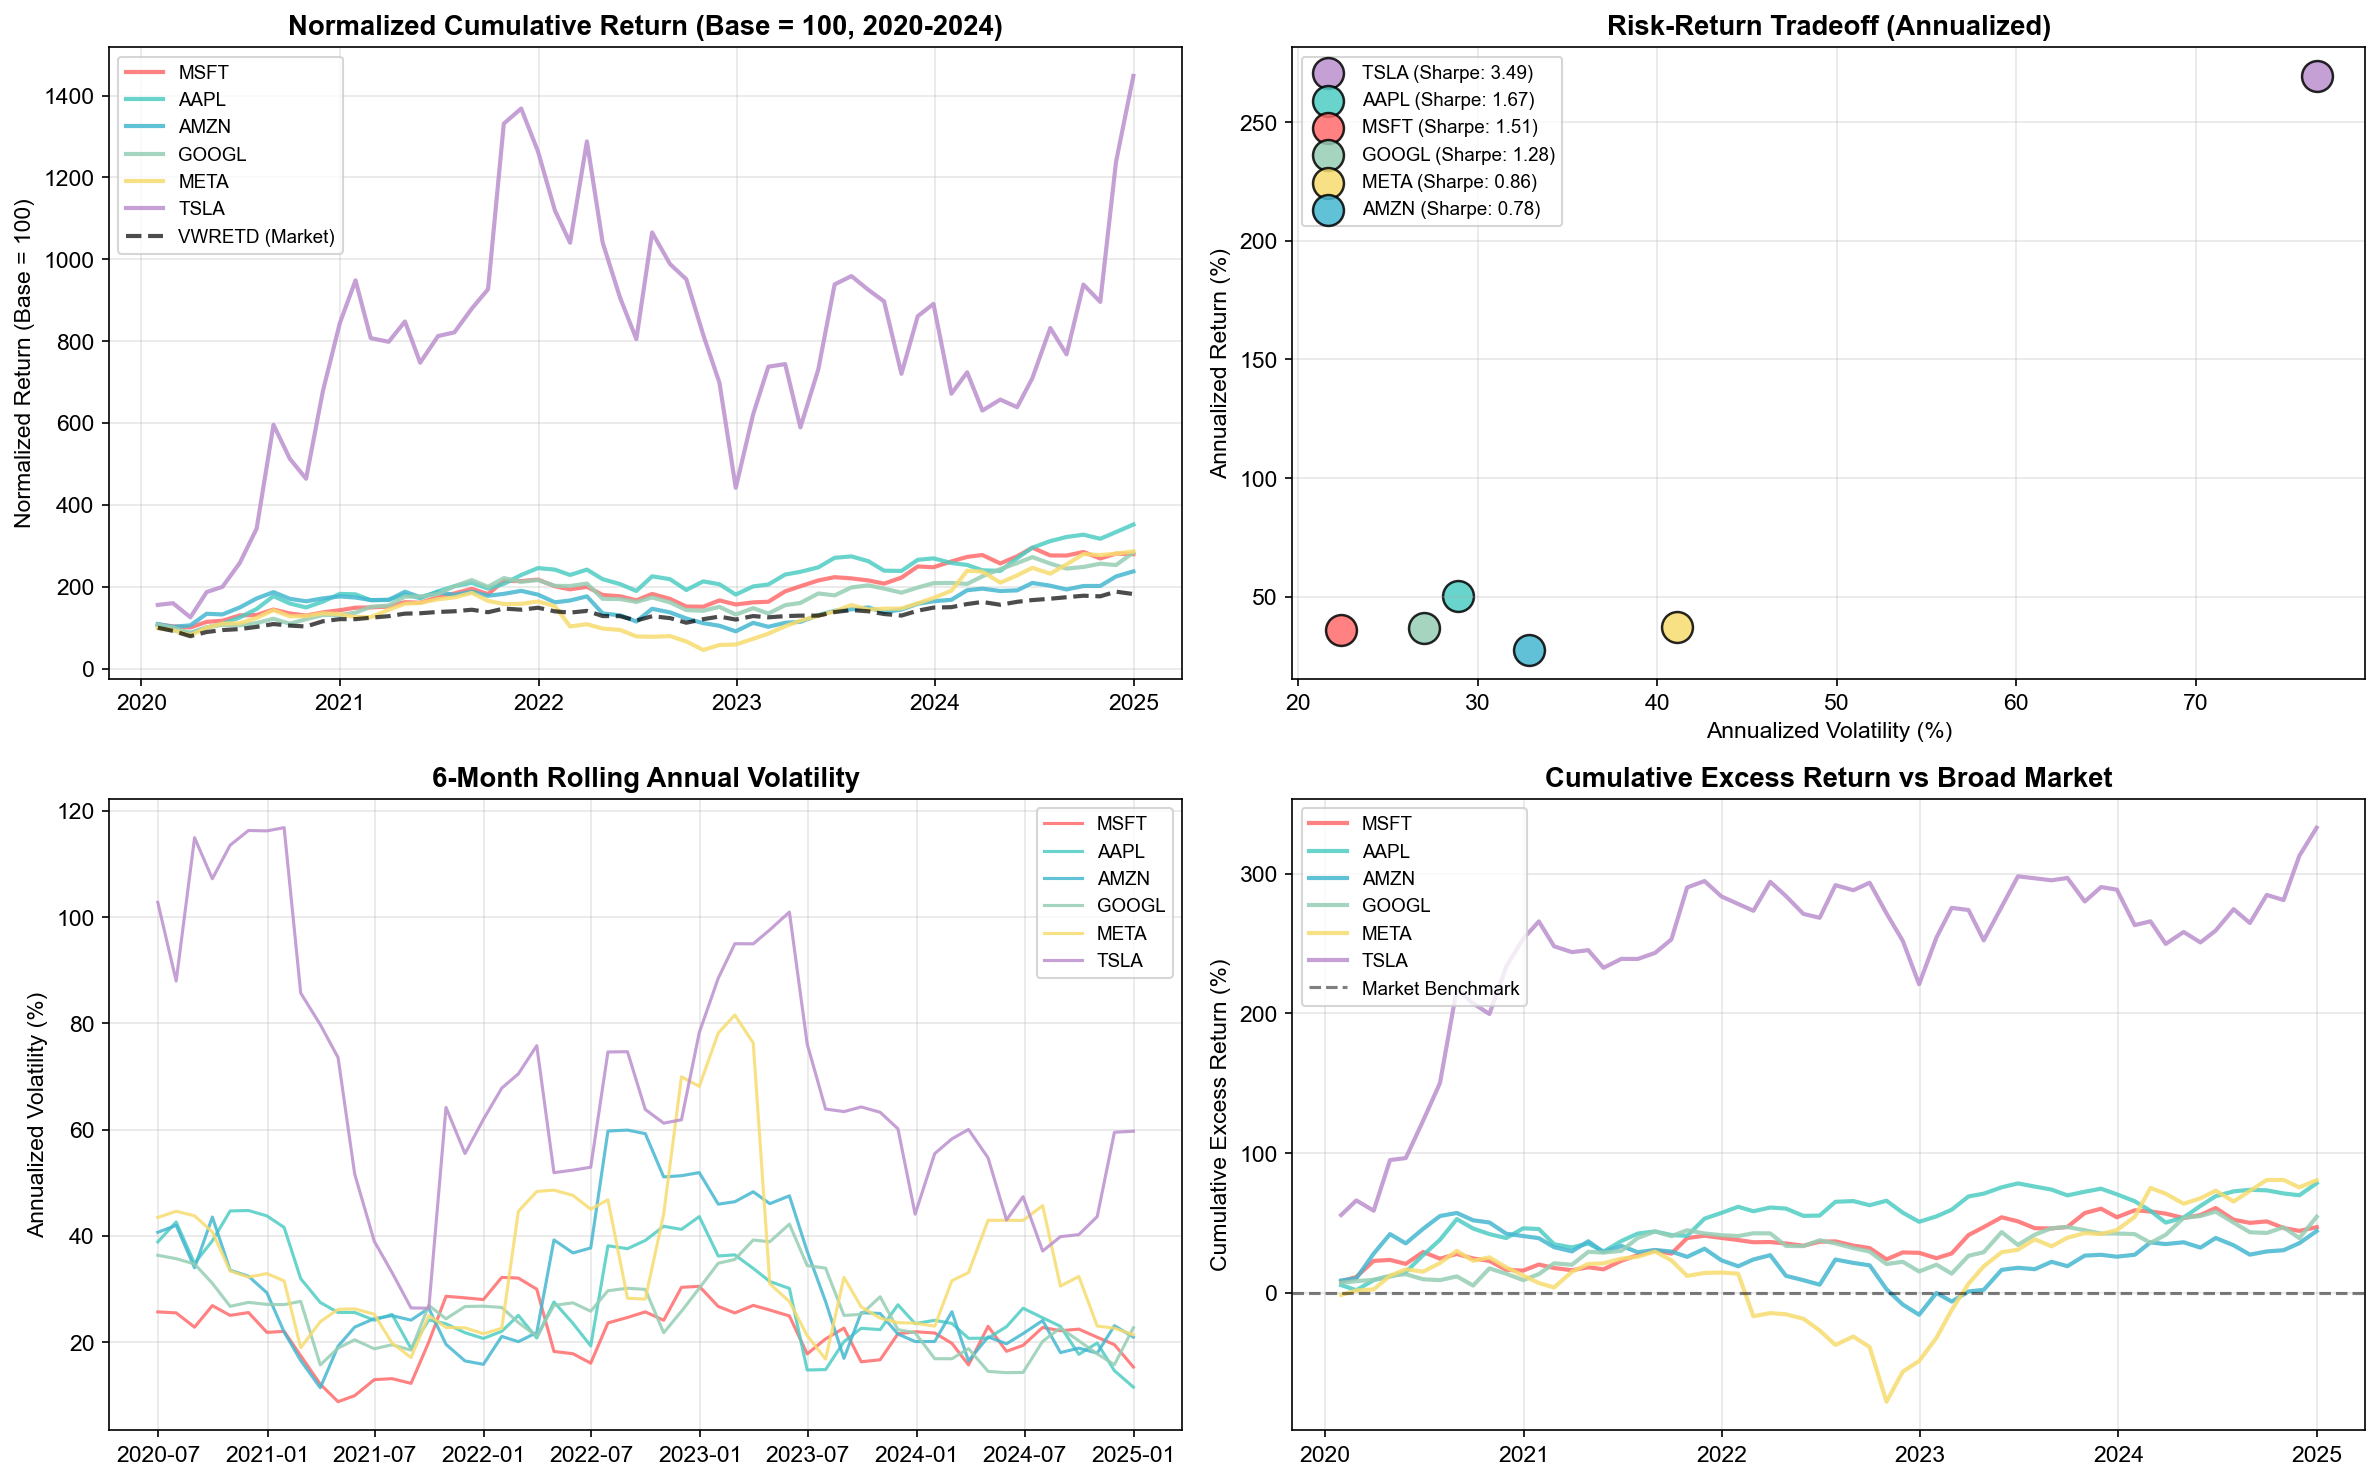


✅ Visualizations saved to: C:\Users\lanove\Desktop\Tech_Stock_Analysis_WRDS\04_Visualizations\tech_stock_performance_plots.png


In [9]:
# --------------------------
# Academic-Standard Visualizations
# --------------------------
def generate_performance_plots(
    normalized_df: pd.DataFrame,
    metrics_df: pd.DataFrame,
    benchmark: str,
    ticker_list: List[str]
):
    """Generate 4 core visualizations for performance analysis"""
    # Define consistent color palette
    color_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F7DC6F', '#BB8FCE']
    ticker_color_map = dict(zip(ticker_list, color_palette[:len(ticker_list)]))

    # Create 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    # Plot 1: Normalized Cumulative Return Trend
    ax1 = axes[0]
    for ticker in ticker_list:
        ticker_subset = normalized_df[normalized_df['ticker'] == ticker]
        ax1.plot(ticker_subset['date'], ticker_subset['normalized_stock_return'],
                 label=ticker, color=ticker_color_map[ticker], linewidth=2, alpha=0.85)
    # Add market benchmark
    benchmark_subset = normalized_df[normalized_df['ticker'] == ticker_list[0]]
    ax1.plot(benchmark_subset['date'], benchmark_subset['normalized_market_return'],
             label=f'{benchmark.upper()} (Market)', color='black', linewidth=2, linestyle='--', alpha=0.7)
    ax1.set_title('Normalized Cumulative Return (Base = 100, 2020-2024)', fontweight='bold')
    ax1.set_ylabel('Normalized Return (Base = 100)')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Risk-Return Scatter Plot
    ax2 = axes[1]
    for _, row in metrics_df.iterrows():
        ax2.scatter(row['annualized_volatility_pct'], row['annualized_return_pct'],
                    s=220, color=ticker_color_map[row['ticker']], alpha=0.85, edgecolors='black', linewidth=1.2,
                    label=f"{row['ticker']} (Sharpe: {row['sharpe_ratio']})")
    ax2.set_title('Risk-Return Tradeoff (Annualized)', fontweight='bold')
    ax2.set_xlabel('Annualized Volatility (%)')
    ax2.set_ylabel('Annualized Return (%)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Rolling Volatility Trend
    ax3 = axes[2]
    for ticker in ticker_list:
        ticker_subset = normalized_df[normalized_df['ticker'] == ticker].copy()
        ticker_subset['rolling_annual_vol'] = ticker_subset['ret'].rolling(ROLLING_WINDOW).std() * np.sqrt(12) * 100
        ax3.plot(ticker_subset['date'], ticker_subset['rolling_annual_vol'],
                 label=ticker, color=ticker_color_map[ticker], linewidth=1.5, alpha=0.85)
    ax3.set_title(f'{ROLLING_WINDOW}-Month Rolling Annual Volatility', fontweight='bold')
    ax3.set_ylabel('Annualized Volatility (%)')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    # Plot 4: Cumulative Excess Return vs Market
    ax4 = axes[3]
    for ticker in ticker_list:
        ticker_subset = normalized_df[normalized_df['ticker'] == ticker].copy()
        ticker_subset['monthly_excess'] = (ticker_subset['ret'] - ticker_subset[benchmark]) * 100
        ticker_subset['cumulative_excess'] = ticker_subset['monthly_excess'].cumsum()
        ax4.plot(ticker_subset['date'], ticker_subset['cumulative_excess'],
                 label=ticker, color=ticker_color_map[ticker], linewidth=2, alpha=0.85)
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Market Benchmark')
    ax4.set_title('Cumulative Excess Return vs Broad Market', fontweight='bold')
    ax4.set_ylabel('Cumulative Excess Return (%)')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    # Adjust layout and save high-resolution plot
    plt.tight_layout()
    plot_save_path = os.path.join(MAIN_BACKUP_PATH, "04_Visualizations", "tech_stock_performance_plots.png")
    plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Visualizations saved to: {plot_save_path}")

# Generate plots
generate_performance_plots(rebased_data, performance_metrics, MARKET_BENCHMARK, TARGET_TICKERS)

In [10]:
# --------------------------
# Export Full Results & Clean Up
# --------------------------
# Export all results to a single Excel file with multiple sheets
excel_export_path = os.path.join(MAIN_BACKUP_PATH, "03_Analysis_Results", "full_analysis_results.xlsx")
with pd.ExcelWriter(excel_export_path, engine='openpyxl') as writer:
    stock_raw_data.to_excel(writer, sheet_name='Raw_WRDS_Stock_Data', index=False)
    market_raw_data.to_excel(writer, sheet_name='Raw_Market_Data', index=False)
    cleaned_full_data.to_excel(writer, sheet_name='Cleaned_Merged_Data', index=False)
    rebased_data.to_excel(writer, sheet_name='Normalized_Rebased_Data', index=False)
    performance_metrics.to_excel(writer, sheet_name='Performance_Metrics', index=False)

print(f"📊 Full analysis results exported to Excel: {excel_export_path}")

# Close WRDS database connection
if db is not None:
    db.close()
    print("🔌 WRDS database connection closed successfully.")

# Final completion summary
print("\n🎉 ANALYSIS COMPLETED SUCCESSFULLY 🎉")
print(f"All files are saved in your desktop folder: Tech_Stock_Analysis_WRDS")
print("You can use all outputs directly for your assignment submission and analysis reporting.")

📊 Full analysis results exported to Excel: C:\Users\lanove\Desktop\Tech_Stock_Analysis_WRDS\03_Analysis_Results\full_analysis_results.xlsx
🔌 WRDS database connection closed successfully.

🎉 ANALYSIS COMPLETED SUCCESSFULLY 🎉
All files are saved in your desktop folder: Tech_Stock_Analysis_WRDS
You can use all outputs directly for your assignment submission and analysis reporting.
